## FASHION-MNIST IMAGE CLASSIFICATION - ASSIGNMENT 0

This assignment is an introduction to the basic concepts in Deep Learning. We will work with image data in order to deploy a simple Multilayer Perceptron (MLP). In particular, we will *classify images of clothing into 10 garment categories* using the **Fashion-MNIST** dataset. The tasks to be implemented are split in three main sections:

* Building Your Deep Neural Network
    * You will learn the basics of how a neural network works step by step: layer definitions, activation functions, forward pass, backward pass and parameter update.
    * All these steps will be implemented in NumPy, and used in Problem 2 for training our model.
* Deep Neural Network for Classification
    * We will perform what is commonly known as an exploratory data analysis (EDA), in which we aim to gain some knowledge about the dataset and get to understand the nature of the data we're dealing with. Since we are dealing with images rather than tabular data, our EDA will look different: instead of inspecting columns and correlations, we will *look at the images themselves*, at how many examples each class has, and at how the pixel intensities are distributed. Such analysis will allow us to know more about the distribution of our data and find anomalies that can potentially affect the training of our AI model.
    * We will develop a preprocessing pipeline. Here we decide how to turn a 28x28 image into something an MLP can consume (flattening), and how to rescale the pixel values so that training behaves well (normalization). At the same time, this step usually includes the data splitting into train, validation and test.
    * Finally, we will make use of the functions in Problem 1 to train our model.
* PyTorch Implementation
    * This problem is an introduction to one of the most well-known Deep Learning frameworks, PyTorch. With this framework, you will build the same network we used in the previous problem from scratch, and you will see the difference in both performance and time.
    * PyTorch gives you `torch.nn` to define the layers of a model and `torch.autograd` to compute all the gradients automatically, so you never need to write the backward pass by hand again. Unlike higher-level APIs such as Keras, PyTorch has no `.fit()` method: **you write the training loop yourself**, which keeps the same five steps you implemented in Problem 1 (forward, cost, backward, update, repeat) explicitly visible in the code.

Let's get dirty!

In [1]:
# Utilities provided for you.
# These are the activation functions and the backward-propagation helpers that you will use
# throughout Problem 1 and Problem 2. Read them if you are curious, but you do not need to
# modify anything here.

import numpy as np


# ------------------------------------------------------------------ activations (forward)

def sigmoid(Z):
    """Sigmoid activation. Returns the activation A and a cache containing Z."""
    A = 1.0 / (1.0 + np.exp(-Z))
    return A, Z


def relu(Z):
    """ReLU activation. Returns the activation A and a cache containing Z."""
    A = np.maximum(0, Z)
    return A, Z


def softmax(Z):
    """
    Softmax activation over the *class* axis (axis 0, since our data is (features, samples)).

    We subtract the per-column maximum before exponentiating. This does not change the result
    mathematically -- softmax(z) == softmax(z - c) for any constant c -- but it keeps exp()
    from overflowing when the logits are large. This is the same "numerical stability" trick
    that PyTorch's CrossEntropyLoss uses internally.
    """
    Z_shifted = Z - np.max(Z, axis=0, keepdims=True)
    exp_Z = np.exp(Z_shifted)
    A = exp_Z / np.sum(exp_Z, axis=0, keepdims=True)
    return A, Z


# ------------------------------------------------------------------ activations (backward)

def sigmoid_backward(dA, Z):
    """Gradient of the sigmoid: dZ = dA * s * (1 - s)."""
    s = 1.0 / (1.0 + np.exp(-Z))
    return dA * s * (1 - s)


def relu_backward(dA, Z):
    """Gradient of the ReLU: the gradient flows only where Z was positive."""
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ


# ------------------------------------------------------------------ backward propagation

def linear_backward(dZ, linear_cache):
    """
    Backward pass of the linear module Z = W A_prev + b.

    dW      = 1/m * dZ . A_prev^T
    db      = 1/m * sum(dZ)
    dA_prev = W^T . dZ
    """
    A_prev, W, b = linear_cache
    m = A_prev.shape[1]

    dW = (1.0 / m) * np.dot(dZ, A_prev.T)
    db = (1.0 / m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)

    return dA_prev, dW, db


def linear_activation_backward(dA, cache, activation):
    """Backward pass for one layer: first through the activation, then through the linear module."""
    linear_cache, activation_cache = cache

    if activation == "relu":
        dZ = relu_backward(dA, activation_cache)
    elif activation == "sigmoid":
        dZ = sigmoid_backward(dA, activation_cache)
    elif activation == "linear":
        dZ = dA
    else:
        raise ValueError("Unknown activation: %s" % activation)

    return linear_backward(dZ, linear_cache)


def L_model_backward(y_pred, Y, caches):
    """
    Backward propagation for the whole [LINEAR -> RELU] * (L-1) -> [LINEAR -> SOFTMAX] model.

    Arguments:
    y_pred -- output of L_model_forward(), the predicted probabilities, shape (n_classes, m)
    Y      -- true labels, ONE-HOT encoded, same shape as y_pred
    caches -- list of caches returned by linear_activation_forward()

    Returns:
    grads -- dictionary with dA, dW and db for every layer
    """
    grads = {}
    L = len(caches)
    Y = Y.reshape(y_pred.shape)

    # ---- Output layer -------------------------------------------------------------------
    # For a softmax output combined with the categorical cross-entropy cost, the gradient
    # collapses to a remarkably simple expression:
    #
    #       dZ[L] = y_pred - Y
    #
    # so we can skip computing dA[L] and go straight to the linear backward step.
    linear_cache, _ = caches[L - 1]
    dZL = y_pred - Y
    grads["dA" + str(L - 1)], grads["dW" + str(L)], grads["db" + str(L)] = \
        linear_backward(dZL, linear_cache)

    # ---- Hidden layers (ReLU), walked backwards -----------------------------------------
    for l in reversed(range(L - 1)):
        dA_prev, dW, db = linear_activation_backward(grads["dA" + str(l + 1)], caches[l], "relu")
        grads["dA" + str(l)] = dA_prev
        grads["dW" + str(l + 1)] = dW
        grads["db" + str(l + 1)] = db

    return grads


# ------------------------------------------------------------------ test cases

def compute_cost_test_case():
    """Small one-hot / prediction pair to sanity-check compute_cost()."""
    np.random.seed(1)
    labels = np.array([3, 7, 1, 0])
    Y = np.eye(10)[labels].T                 # (10, 4) one-hot
    y_pred, _ = softmax(np.random.randn(10, 4))
    return Y, y_pred


def update_parameters_test_case():
    """Small parameter / gradient pair to sanity-check update_parameters()."""
    np.random.seed(2)
    parameters = {"W1": np.random.randn(3, 4), "b1": np.random.randn(3, 1),
                  "W2": np.random.randn(1, 3), "b2": np.random.randn(1, 1)}
    np.random.seed(3)
    grads = {"dW1": np.random.randn(3, 4), "db1": np.random.randn(3, 1),
             "dW2": np.random.randn(1, 3), "db2": np.random.randn(1, 1)}
    return parameters, grads


print("Utilities loaded_.")

Utilities loaded_.


## Problem 1.  Building your Deep Neural Network

In this problem, you will implement all the functions required to build a fully-connected neural network in NumPy. The aim is to provide you with insights about the mathematical and statistics behind the neural networks. These functions will be then used to build a deep neural network for image classification in Problem 2.

**Notation**:

In the images and text included in this notebook, you will find a large variety of symbols. Here you have a description of them:
- $X$ denotes the training data.
- $W$ and $b$ denote the layer parameters (weights and bias). Remember, weights are numerical values associated with the connection strength between neurons, and biases are essentially constants associated with each neuron that serve as a form of offset or threshold, allowing neurons to activate even when the weighted sum of their inputs is not sufficient on its own.
- $Y$ denotes the true "label" vectors. Since we now have $C = 10$ classes, $Y$ is **one-hot encoded**: the label "Sandal" (class 5) becomes the column vector $[0,0,0,0,0,1,0,0,0,0]^T$.
- $Z$ denotes the linear forward module.
- $A$ denotes the activation.

Throughout Problems 1 and 2 we keep the data in **(features, samples)** orientation, i.e. one *column* per image. So a batch of $m$ Fashion-MNIST images has shape $(784, m)$ and the corresponding labels have shape $(10, m)$.

Let's get started!

### 1 - Outline of the Problem

Here is an outline of this problem, you will:

- Initialize the parameters for a $L$-layer neural network.
- Implement the forward propagation module.
     - Forward propagation: Complete the LINEAR combination of the parameters and apply the ACTIVATION function.
     - Stack the forward propagation function according to the number of hidden layers and add the output layer (classifier) with the proper ACTIVATION.
- Compute the loss.
- Implement the backward propagation module.
    - Backward propagation.
    - Stack the backward propagation function according to the number of hidden layers and add the output layer.
- Finally update the parameters.

**Note that for every forward function, there is a corresponding backward function. That is why at every step of your forward module you will be storing some values in a cache. The cached values are useful for computing gradients. In the backpropagation module the cache is used to calculate the gradients.**

### 2 - Initialization

We will write two helper functions that will initialize the parameters for your model. The first function will be used to initialize parameters for an L-layer model. The shape of the parameters will be given by the number of units on each layer.

<img src="https://upload.wikimedia.org/wikipedia/commons/4/46/Colored_neural_network.svg" width="250">

**Instructions**:
- Use random initialization for the weight matrices. Use `np.random.randn(shape) / np.sqrt(layer_dims[l-1])` with the correct shape. This is called LeCun Initialization as we are using `1 / np.sqrt(layer_dims[l-1])` to normalize the variance of the weights.
- Use zeros initialization for the biases. Use `np.zeros(shape)`  with the correct shape...

In [2]:
def initialize_parameters(layer_dims):
    """
    Arguments:
    layer_dims -- python array (list) containing the dimensions of each layer in our network (input, hidden_1, ..., hidden_n, output)

    Returns:
    parameters -- python dictionary containing your parameters "W1", "b1", ..., "WL", "bL":
                    Wl -- weight matrix of shape (layer_dims[l], layer_dims[l-1])
                    bl -- bias vector of shape (layer_dims[l], 1)
    """

    np.random.seed(3)
    parameters = {}
    L = len(layer_dims) # number of layers in the network

    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layer_dims[l],layer_dims[l-1]) / np.sqrt(layer_dims[l-1])
        parameters['b' + str(l)] = np.zeros((layer_dims[l],1))

        assert(parameters['W' + str(l)].shape == (layer_dims[l], layer_dims[l-1]))
        assert(parameters['b' + str(l)].shape == (layer_dims[l], 1))

    return parameters

In [3]:
# Set up some test inputs
np.random.seed(1)
layer_dims = [5,4,3]
parameters = initialize_parameters(layer_dims)

print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

W1 = [[ 0.79989897  0.19521314  0.04315498 -0.83337927 -0.12405178]
 [-0.15865304 -0.03700312 -0.28040323 -0.01959608 -0.21341839]
 [-0.58757818  0.39561516  0.39413741  0.76454432  0.02237573]
 [-0.18097724 -0.24389238 -0.69160568  0.43932807 -0.49241241]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
W2 = [[-0.59252326 -0.10282495  0.74307418  0.11835813]
 [-0.51189257 -0.3564966   0.31262248 -0.08025668]
 [-0.38441818 -0.11501536  0.37252813  0.98805539]]
b2 = [[0.]
 [0.]
 [0.]]


#### Question 1 &mdash; shapes

You did not have to write `initialize_parameters()`, but you do need to be able to predict what it produces. Suppose we build the network with `layer_dims = [784, 16, 32, 64, 10]`.

1. What are the shapes of `W2` and `b3`?
2. Every bias has shape `(n, 1)` rather than `(n, m)`, where `m` is the number of images. Why is one column enough?

<details>
<summary><i>Work it out first, then click here.</i></summary>

**1.** `W2` has shape `(32, 16)` and `b3` has shape `(64, 1)`.

The rule is `W[l].shape == (layer_dims[l], layer_dims[l-1])`. It reads backwards from what you might expect, and the reason is the orientation we chose: our data has one *column* per image, so a layer computes `Z = W A_prev + b` where `A_prev` is `(n_prev, m)`. For that matrix product to work, `W` must be `(n_current, n_prev)`.

**2.** Because of **broadcasting**. Every image in the batch gets the *same* bias added to it, so storing `m` identical copies would be pure waste. NumPy stretches the `(n, 1)` column across all `m` columns automatically. This is also why `db` is computed with `np.sum(dZ, axis=1, keepdims=True)` in the backward pass: the single bias influenced all `m` predictions, so its gradient collects contributions from all of them.

</details>

### 3 - Forward propagation module

The forward propagation module consists of applying the same mathematical calculation on a single perceptron to every unit of the network.

<img src="https://cdn-wordpress-info.futurelearn.com/info/wp-content/uploads/6fd7c8cc-1e75-4bd3-9fa1-03e099115c8b.png" width="500">

<img src="https://upload.wikimedia.org/wikipedia/commons/4/46/Colored_neural_network.svg" width="250">

### 3.1 - Forward propagation function

Now that you have initialized your parameters, you will do the forward propagation module. You will start by implementing the basic forward propagation step for a single layer, and then apply it in a L-layer model.

The linear forward module (vectorized over all the examples) for the $[l]$-layer computes the following equation:

$Z^{[l]} = W^{[l]}A^{[l-1]} +b^{[l]}$

where $A^{[0]} = X$. Then, the activation function $g(.)$ (relu, sigmoid or softmax) is applied:

$A^{[l]} = g(Z^{[l]})$

The activation functions were provided in the utilities cell at the top of the notebook. All of them return **two** items: the activation value "`A`" and a "`cache`" that contains "`Z`" (it's what we will feed in to the corresponding backward function).

- **Sigmoid**: $\sigma(Z) = \frac{1}{ 1 + e^{-Z}}$. Squashes a single number into $(0,1)$. To use it you could just call:
``` python
A, activation_cache = sigmoid(Z)
```

- **ReLU**: The mathematical formula for ReLu is $A = RELU(Z) = max(0, Z)$. To use it you could just call:
``` python
A, activation_cache = relu(Z)
```

- **Softmax**: $\text{softmax}(Z)_c = \frac{e^{Z_c}}{\sum_{k=1}^{C} e^{Z_k}}$. This is the multi-class generalization of the sigmoid: it turns a vector of $C$ raw scores into $C$ probabilities that are all positive and **sum to 1**. This is what we need at the output layer now that we are choosing between 10 garments instead of answering a yes/no question. To use it you could just call:
``` python
A, activation_cache = softmax(Z)
```

In [4]:
def linear_activation_forward(A_prev, W, b, activation):
    """
    Implement the forward propagation for a layer

    Arguments:
    A_prev -- activations from previous layer (or input data): (size of previous layer, number of examples)
    W -- weights matrix: numpy array of shape (size of current layer, size of previous layer)
    b -- bias vector, numpy array of shape (size of the current layer, 1)
    activation -- the activation to be used in this layer, stored as a text string: "sigmoid", "softmax", "linear" or "relu"

    Returns:
    A -- the output of the activation function, also called the post-activation value
    cache -- a python tuple containing "linear_cache" and "activation_cache";
             stored for computing the backward pass efficiently
    """

    # Linear module and linear cache
    Z = np.dot(W, A_prev) + b
    linear_cache = (A_prev, W, b)

    # Activation
    if activation == "sigmoid":
        A, activation_cache = sigmoid(Z) # This "activation_cache" contains "Z"

    elif activation == "relu":
        A, activation_cache = relu(Z) # This "activation_cache" contains "Z"

    elif activation == "softmax":
        A, activation_cache = softmax(Z) # This "activation_cache" contains "Z"

    elif activation == "linear":
        A = activation_cache = Z # This "activation_cache" contains "Z"

    assert (A.shape == (W.shape[0], A_prev.shape[1]))
    cache = (linear_cache, activation_cache)

    return A, cache

#### 3.2 Forward propagation for a L-layer model

For even more convenience when implementing the $L$-layer Neural Net, you will need a function that replicates the forward propagation function on each layer. Let's implement the forward propagation of a model with $L-1$ hidden layers with ReLU activation followed by one output layer with **softmax** activation.

**Tips**:
- In the code below, the variable `y_pred` will denote the predictions. It refers to $\hat{y} = A^{[L]} = \text{softmax}(Z^{[L]}) = \text{softmax}(W^{[L]} A^{[L-1]} + b^{[L]})$.
- `y_pred` now has shape $(C, m) = (10, m)$: one column per image, and within each column one probability per garment class. Each column sums to 1.
- Don't forget to keep track of the caches in the "caches" list. To add a new value `c` to a `list`, you can use `list.append(c)`.

In [5]:
def L_model_forward(X, parameters):
    """
    Implement forward propagation for the L-layer model computation

    Arguments:
    X -- data, numpy array of shape (input size, number of examples)
    parameters -- output of initialize_parameters()

    Returns:
    y_pred -- last post-activation value (predicted class probabilities), shape (n_classes, m)
    caches -- list of caches containing:
                every cache of linear_activation_forward() (there are L of them, indexed from 0 to L-1)
    """

    caches = []
    A = X
    L = len(parameters) // 2 # number of layers in the neural network

    # ---------------------------------------------------------------- YOUR DECISION -----
    # Pick the activation used by the HIDDEN layers, and the one used by the OUTPUT layer.
    # Available in linear_activation_forward():  "relu"  "sigmoid"  "softmax"  "linear"
    #
    # Think about what each layer is FOR before you choose. The output layer of a 10-class
    # classifier has a job the hidden layers do not have -- and there is a reason we bothered
    # to write a softmax() helper at the top of this notebook.
    hidden_activation = 'relu'
    output_activation = 'softmax'
    # ------------------------------------------------------------------------------------

    # Implement the hidden layers
    for l in range(1, L):
        A_prev = A

        A, cache = linear_activation_forward(A_prev, parameters['W' + str(l)], parameters['b' + str(l)], hidden_activation)
        caches.append(cache)

    # Implement the output layer. Add "cache" to the "caches" list.
    y_pred, cache = linear_activation_forward(A, parameters['W' + str(L)], parameters['b' + str(L)], output_activation)
    caches.append(cache)

    n_classes = parameters['W' + str(L)].shape[0]
    assert(y_pred.shape == (n_classes, X.shape[1]))

    return y_pred, caches

#### Question 2 &mdash; the output layer

You just chose the output activation. Interrogate that choice:

1. Why does the output layer have **10 units and a softmax**, instead of **1 unit and a sigmoid** like a yes/no classifier would?
2. What concretely goes wrong if you put `"relu"` on the output layer instead?
3. The hidden layers use ReLU. Would sigmoid work there too? What would you lose?

<details>
<summary><i>Commit to an answer, then click here.</i></summary>

**1.** A sigmoid unit answers *one* yes/no question. We are asking "which of 10?", which is a different question: the answers are **mutually exclusive** and must be **jointly exhaustive**. Softmax builds both properties in, because it normalizes by the sum over all 10 classes, so the outputs are guaranteed to be positive and to sum to 1. Ten independent sigmoids could happily output 0.9 for both "Sneaker" and "Ankle boot", or 0.01 for everything, and neither is a coherent probability distribution over garments.

**2.** ReLU outputs any number in `[0, ∞)`. Those are not probabilities, so `compute_cost` would take the log of unnormalized values, and every unit that happens to output exactly 0 makes `log(0)` -- which is why we added that `epsilon` guard. You would get a number, the training would run, and the results would be quietly meaningless. This is the dangerous kind of bug: no crash, just garbage.

**3.** It would train, but worse. Sigmoid **saturates** -- for large positive or negative `Z` its gradient is nearly zero, so those neurons stop learning, and the effect compounds across layers (the *vanishing gradient* problem). ReLU's gradient is exactly 1 for all positive inputs, so the signal survives the trip back through a deep stack. This is a large part of why deep networks became trainable at all.

</details>

Great! Now you have a full forward propagation that takes the input X and outputs a matrix $\hat{y}$ of shape $(10, m)$ containing, for every image, the probability of each of the 10 garment classes. It also records all intermediate values in "caches". Using $\hat{y}$, you can compute the cost of your predictions.

### 4 - Cost function

Between the forward and backward propagation steps, you need to compute the cost (or loss), because you want to check if your model is actually learning. To do so, we compute the **categorical cross-entropy** cost $J$, using the following formula:

$J = -\frac{1}{m} \sum\limits_{i = 1}^{m} \sum\limits_{c = 1}^{C} y_c^{(i)}\log\left(\hat{y}_c^{(i)}\right)$

where $C = 10$ is the number of classes and $y^{(i)}$ is the one-hot encoded label of image $i$.

Notice that this is the natural generalization of the binary cross-entropy. Because $y^{(i)}$ is one-hot, the inner sum has exactly **one** non-zero term: the one corresponding to the correct class. So the cost is really just "the average of $-\log(\text{probability the model assigned to the right answer})$". If the model puts probability 1 on the correct garment, the cost contribution is $-\log(1) = 0$; if it puts probability close to 0 on it, the cost explodes.

**Note.** We add a tiny `epsilon` inside the logarithm. A perfectly confident-but-wrong prediction would give $\log(0) = -\infty$ and poison the whole computation with `nan`, so this guard keeps the cost finite.

In [6]:
def compute_cost(y_pred, Y):
    """
    Implement the categorical cross-entropy loss function.

    Arguments:
    y_pred -- probability matrix corresponding to your label predictions, shape (n_classes, number of examples)
    Y -- true "label" matrix, ONE-HOT encoded, shape (n_classes, number of examples)

    Returns:
    cost -- categorical cross-entropy cost
    """

    m = Y.shape[1]
    epsilon = 1e-8  # avoids log(0)

    # Compute loss from y_pred and Y.
    cost = -1 / m * np.sum(Y * np.log(y_pred + epsilon))

    cost = np.squeeze(cost)      # To make sure your cost's shape is what we expect (e.g. this turns [[17]] into 17).
    assert(cost.shape == ())

    return cost

In [7]:
# Set up some test inputs
Y, y_pred = compute_cost_test_case()

print("cost = " + str(compute_cost(y_pred, Y)))

cost = 2.3619343546211145


### 5 - Backward propagation module

#### 5.1 - Backpropagation function

Backpropagation is used to calculate the gradient of the loss function with respect to the parameters. The gradient is then used to update the parameters. This whole process is the "learning" step. The mathematics behind the backpropagation step are based on the [chain rule](https://en.wikipedia.org/wiki/Chain_rule) of calculus. It states that if a variable $\theta$ depends on the variable $\gamma$, which itself depends on the variable $\phi$, then $\theta$ depends on $\phi$ as well, via the intermediate variable $\gamma$. Then, the derivate of $\theta$ wrt $\phi$ can be expressed as:

$\theta = \gamma (\phi) \rightarrow \frac{d\theta}{d\phi} = \frac{d\theta}{d\gamma} \cdot \frac{d\gamma}{d\phi}$

This means that, if we want to find the gradients of the parameters in the first layer of a 3-layer neural network, we need first to compute the gradients in the second and third layers. That's why we talk about **backpropagation**.

As you can imagine, this step occurs backward, i.e., it starts from the cost function and calculates gradients backward. For each layer $[l]$:
- The gradient of the linear module is assessed using the derivate of the activation funtion $g'(.)$: $dZ^{[l]} = dA^{[l]} \cdot g'(Z^{[l]})$
- The gradient of the cost with respect to the previous activation $dA^{[l-1]}$ is estimated:

    $dA^{[l-1]} = \frac{\partial \mathcal{L} }{\partial A^{[l-1]}} = W^{[l] T} dZ^{[l]}$

- The gradients of the parameters are calculated:

    $dW^{[l]} = \frac{\partial \mathcal{J} }{\partial W^{[l]}} = \frac{1}{m} dZ^{[l]} A^{[l-1] T}$

    $db^{[l]} = \frac{\partial \mathcal{J} }{\partial b^{[l]}} = \frac{1}{m} \sum_{i = 1}^{m} dZ^{[l](i)}$

**The softmax shortcut.** At the output layer something very convenient happens. If you work through the derivative of the categorical cross-entropy cost with respect to the *logits* $Z^{[L]}$, the messy softmax Jacobian cancels out almost entirely and you are left with:

$dZ^{[L]} = \hat{y} - Y$

That is, "predicted probability minus one-hot truth". This is why softmax and cross-entropy are almost always used as a pair, and it is exactly the same reason PyTorch bundles them together in `nn.CrossEntropyLoss`. It is also the reason `L_model_backward()` below can skip computing $dA^{[L]}$ altogether and jump straight into the linear backward step.

For simplicity, you will skip the implementation of the backpropagation step. If you are interested in the operations behind, feel free to take a look at the `linear_activation_backward()` and `L_model_backward()` functions provided in the utilities cell at the top of this notebook. For more information about backpropagation, visit this [explanation](https://www.youtube.com/watch?v=An5z8lR8asY).

#### 5.2 - Update Parameters

In this section you will update the parameters of the model, using gradient descent:

$ W^{[l]} = W^{[l]} - \alpha \text{ } dW^{[l]} $

$ b^{[l]} = b^{[l]} - \alpha \text{ } db^{[l]} $

where $\alpha$ is the learning rate. After computing the updated parameters, store them in the parameters dictionary.

In [8]:
def update_parameters(parameters, grads, learning_rate):
    """
    Update parameters using gradient descent

    Arguments:
    parameters -- python dictionary containing your parameters
    grads -- python dictionary containing your gradients, output of L_model_backward

    Returns:
    parameters -- python dictionary containing your updated parameters
                  parameters["W" + str(l)] = ...
                  parameters["b" + str(l)] = ...
    """

    L = len(parameters) // 2 # number of layers in the neural network

    # Update rule for each parameter. Use a for loop.
    for l in range(L):
        parameters["W" + str(l+1)] = parameters["W" + str(l+1)] - learning_rate * grads["dW" + str(l+1)]
        parameters["b" + str(l+1)] = parameters["b" + str(l+1)] - learning_rate * grads["db" + str(l+1)]

    return parameters

In [9]:
# Set up some test inputs
parameters, grads = update_parameters_test_case()
parameters = update_parameters(parameters, grads, 0.1)

print ("W1 = "+ str(parameters["W1"]))
print ("b1 = "+ str(parameters["b1"]))
print ("W2 = "+ str(parameters["W2"]))
print ("b2 = "+ str(parameters["b2"]))

W1 = [[-0.59562069 -0.09991781 -2.14584584  1.82662008]
 [-1.76569676 -0.80627147  0.51115557 -1.18258802]
 [-1.0535704  -0.86128581  0.68284052  2.20374577]]
b1 = [[-0.04659241]
 [-1.28888275]
 [ 0.53405496]]
W2 = [[-0.55569196  0.0354055   1.32964895]]
b2 = [[-0.84610769]]


## Problem 2. Deep Neural Network for Classification

In this problem, you will put all the previous functions together to build an L-layer neural network. You will use the functions you implemented in the previous problem to build a deep network and apply a classification task!

Let's get started!

### 1 - Exploratory Data Analysis (EDA)

The first thing you'll need to do is to load the dataset. We will use **Fashion-MNIST**, a dataset of 70,000 grayscale images (28x28 pixels) of clothing items, each belonging to one of 10 categories. It was released by Zalando Research as a drop-in replacement for the classic handwritten-digits MNIST, which modern models solve almost perfectly and which is therefore no longer a useful benchmark.

`torchvision` ships a ready-made loader for it, so we do not need to download anything by hand: `datasets.FashionMNIST(root=..., download=True)` fetches the data the first time and reuses the local copy afterwards. If you want to learn more about this dataset, check https://github.com/zalandoresearch/fashion-mnist.

In [10]:
# Importing the right packages in our Python environment.

import numpy as np
import itertools

import torch
from torchvision import datasets

import seaborn as sns
from matplotlib import pyplot as plt

np.random.seed(1)

Download (or load from disk) the training and test splits. Note that, unlike many datasets you will meet in the wild, Fashion-MNIST **comes already split** into a training set and a test set, so we do not need to carve out a test set ourselves.

We pass no `transform` here on purpose: we want the raw data first so that we can inspect it before deciding how to preprocess it.

In [11]:
train_dataset = datasets.FashionMNIST(root="./data", train=True,  download=True)
test_dataset  = datasets.FashionMNIST(root="./data", train=False, download=True)

class_names = train_dataset.classes
print("Number of training images:", len(train_dataset))
print("Number of test images    :", len(test_dataset))
print("Classes                  :", class_names)

100%|██████████| 26.4M/26.4M [00:01<00:00, 21.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 340kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.29MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.3MB/s]

Number of training images: 60000
Number of test images    : 10000
Classes                  : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


It is always important to get familiar with our data in order to make the proper decisions. To begin with it, let's see the type of data we are working with.

With tabular data we would call `.info()` on a DataFrame to see the columns and their types. The equivalent question for image data is: *what shape are the arrays, and what type and range are the values?* The answer determines everything we do next.

In [12]:
# torchvision exposes the underlying arrays directly through .data and .targets
X_train_raw = train_dataset.data.numpy()      # (60000, 28, 28)
y_train_raw = train_dataset.targets.numpy()   # (60000,)
X_test_raw  = test_dataset.data.numpy()       # (10000, 28, 28)
y_test_raw  = test_dataset.targets.numpy()    # (10000,)

print("Images -- shape:", X_train_raw.shape, "| dtype:", X_train_raw.dtype,
      "| min:", X_train_raw.min(), "| max:", X_train_raw.max())
print("Labels -- shape:", y_train_raw.shape, "| dtype:", y_train_raw.dtype,
      "| unique:", np.unique(y_train_raw))

print("\nEach image is 28 x 28 =", 28 * 28, "pixels, stored as 8-bit integers in [0, 255].")

Images -- shape: (60000, 28, 28) | dtype: uint8 | min: 0 | max: 255
Labels -- shape: (60000,) | dtype: int64 | unique: [0 1 2 3 4 5 6 7 8 9]

Each image is 28 x 28 = 784 pixels, stored as 8-bit integers in [0, 255].


We can also get an initial idea of the distribution of our dataset. For instance, let's check the distribution of our label column, i.e. how many examples we have of each garment.

The number of occurances of each class in the dataset = {'T-shirt/top': np.int64(6000), 'Trouser': np.int64(6000), 'Pullover': np.int64(6000), 'Dress': np.int64(6000), 'Coat': np.int64(6000), 'Sandal': np.int64(6000), 'Shirt': np.int64(6000), 'Sneaker': np.int64(6000), 'Bag': np.int64(6000), 'Ankle boot': np.int64(6000)}  



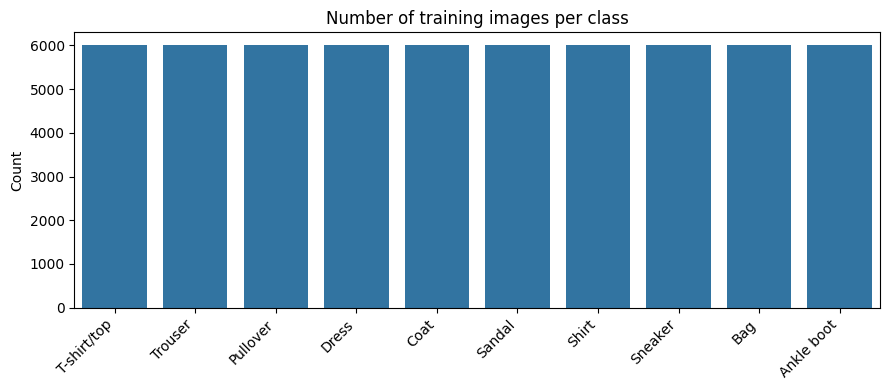

In [13]:
unique, count = np.unique(y_train_raw, return_counts=True)
print("The number of occurances of each class in the dataset = %s "
      % dict(zip([class_names[u] for u in unique], count)), "\n")

plt.figure(figsize=(9, 4))
sns.barplot(x=[class_names[u] for u in unique], y=count)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count")
plt.title("Number of training images per class")
plt.tight_layout()
plt.show()

**Perfectly balanced** -- exactly 6,000 training images per class. This is worth noticing, because it makes our life easier in two ways: accuracy is a meaningful metric here (with an imbalanced dataset, a model that always predicts the majority class can score high while being useless), and we do not need any class weighting or resampling. Real-world datasets are rarely this tidy.

As mentioned before, anomalies are an important aspect when dealing with data. Missing values are one of the most common issues with tabular data. Images are different: a 28x28 array is either there or it is not, so there is no such thing as a "missing pixel" here. What we *can* check is whether the arrays contain any invalid values and whether every pixel really lives in the range we expect.

In [14]:
print("Any NaN in the images? ", np.isnan(X_train_raw).any())
print("Any value outside [0, 255]?", (X_train_raw < 0).any() or (X_train_raw > 255).any())
print("Number of completely black images:", int((X_train_raw.reshape(len(X_train_raw), -1).sum(axis=1) == 0).sum()))

# How much of a typical image is pure background?
frac_zero = (X_train_raw == 0).mean()
print("\nFraction of pixels that are exactly 0 (black background): %.1f%%" % (100 * frac_zero))

Any NaN in the images?  False
Any value outside [0, 255]? False
Number of completely black images: 0

Fraction of pixels that are exactly 0 (black background): 50.2%


**Half of every image is pure black background.** That is our first real insight: a large part of the 784 input features carries very little information, and the pixels near the border are almost always zero. Keep this in mind when we get to normalization -- a feature that barely varies is exactly the kind of thing that misbehaves under a naive per-feature standardization.

Now, the most important EDA step for image data: **actually look at the images**. No amount of summary statistics replaces this.

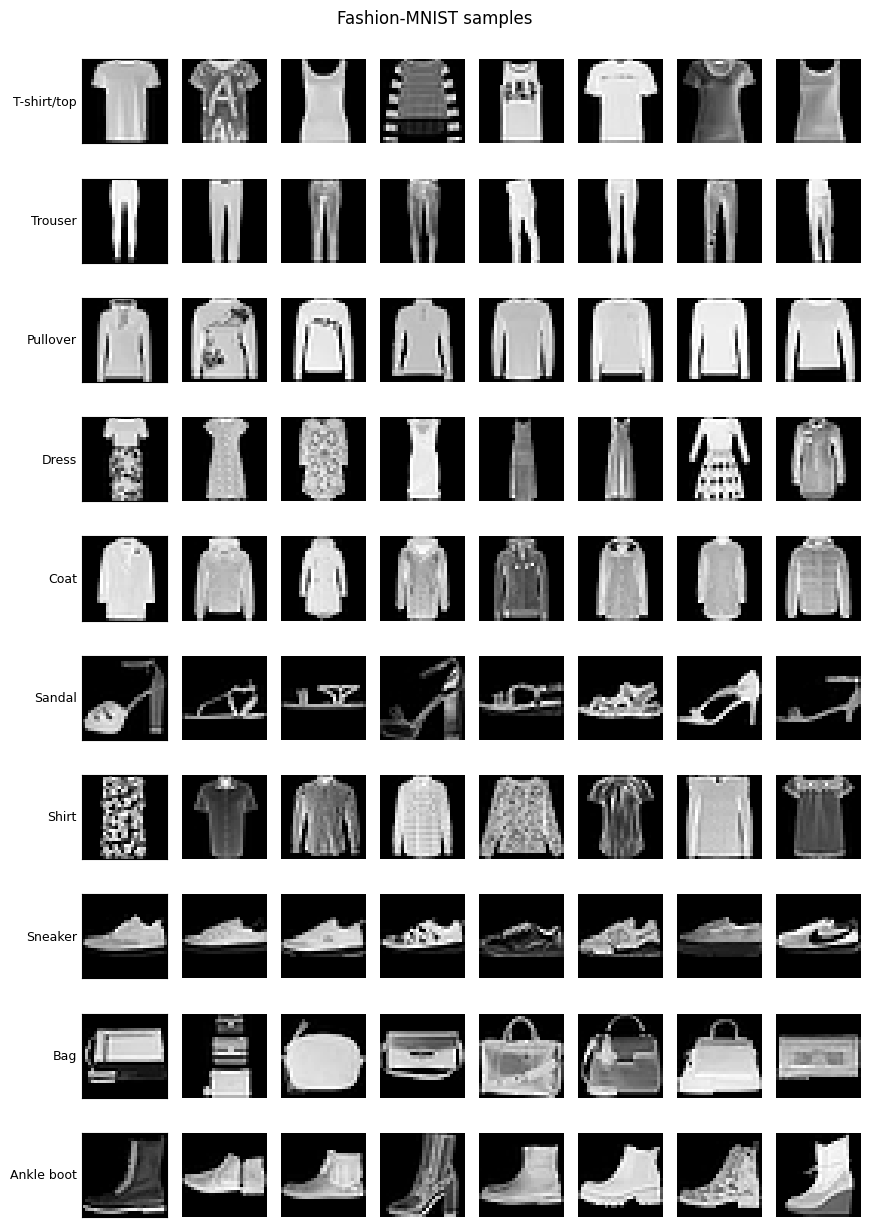

In [15]:
# Show a few examples of every class, one row per class
n_per_class = 8
fig, axes = plt.subplots(len(class_names), n_per_class, figsize=(n_per_class * 1.1, len(class_names) * 1.25))

rng = np.random.default_rng(0)
for row, name in enumerate(class_names):
    idx = rng.choice(np.where(y_train_raw == row)[0], n_per_class, replace=False)
    for col in range(n_per_class):
        ax = axes[row, col]
        ax.imshow(X_train_raw[idx[col]], cmap='gray')
        ax.axis('off')
    axes[row, 0].set_ylabel(name)
    # put the class name to the left of each row
    axes[row, 0].axis('on')
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    axes[row, 0].set_ylabel(name, rotation=0, ha='right', va='center', fontsize=9)

plt.suptitle("Fashion-MNIST samples", y=0.99)
plt.tight_layout()
plt.show()

Already you can see the difficulty of the task: *T-shirt/top*, *Pullover*, *Coat* and *Shirt* are four different classes that all look like "a torso-shaped blob". We should expect our model to confuse them, and we will check exactly that with the confusion matrix at the end of Problem 3.

Another useful view is the **average image of each class**. Averaging thousands of examples washes out the individual details and leaves the shape the network will key on.

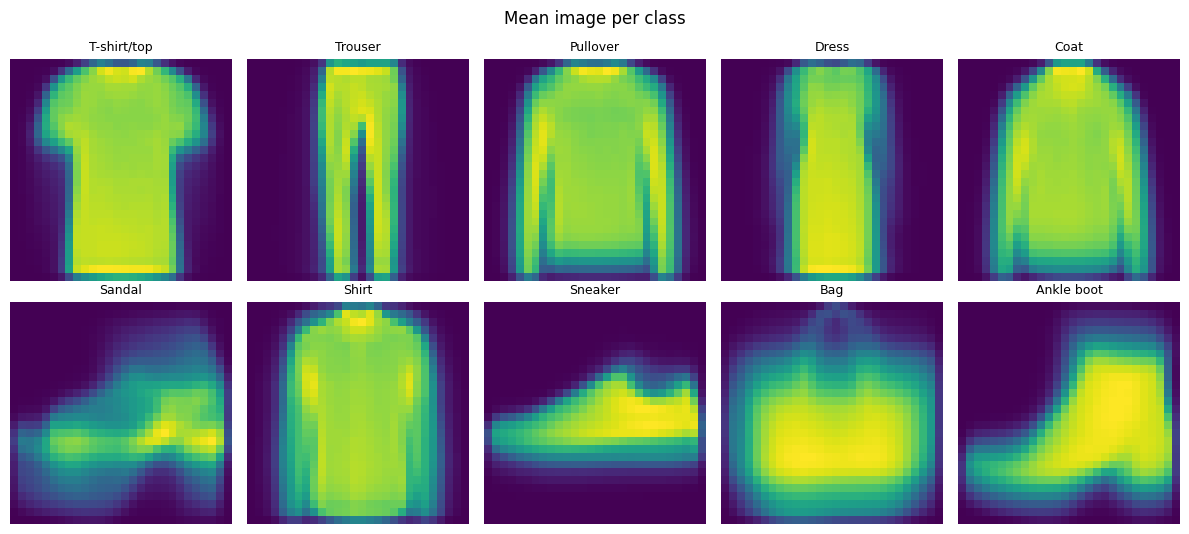

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5.5))

for c, ax in enumerate(axes.flat):
    ax.imshow(X_train_raw[y_train_raw == c].mean(axis=0), cmap='viridis')
    ax.set_title(class_names[c], fontsize=9)
    ax.axis('off')

plt.suptitle("Mean image per class")
plt.tight_layout()
plt.show()

#### Question 3 &mdash; predict before you train

Look back at the sample grid and the mean-image plot, and write down (actually write it down) your answer **before** running anything else:

1. Which **two** classes do you expect the model to confuse most often?:
                                                           Pullover and coat
2. Which class do you expect it to get almost perfectly right?:
                                                           Either bag or trouser

Keep your answer. At the very end of Problem 3 there is a confusion matrix, and you will check it against this prediction.

<details>
<summary><i>Only after you have committed to a guess.</i></summary>

There is no single right answer, but the reasoning matters more than the pick. The four upper-body garments -- **T-shirt/top**, **Pullover**, **Coat** and **Shirt** -- all reduce to a torso-shaped blob with sleeves, and their mean images are nearly indistinguishable. **Shirt** is the usual worst class, because it overlaps all three of the others.

At the easy end, **Trouser** has a unique narrow two-legged silhouette, and **Bag** is the only class with no limbs at all. Both should be near-perfect.

The deeper point: you extracted a real, checkable prediction about model behaviour from twenty seconds of looking at pictures, before training anything. That is what EDA is for.

</details>

Notice how *Trouser*, *Bag* and *Sandal* have very distinctive average silhouettes, while the four upper-body garments have nearly identical ones. This is the same story the sample grid told us, and it predicts where the errors will be.

With tabular data we would now look at the correlation between features to spot redundancy (multicolinearity). We can ask the same question about pixels, and the answer is emphatic: **neighbouring pixels are extremely correlated**, because garments are smooth, contiguous shapes. Let's look at the distribution of pixel intensities and at how much each pixel actually varies across the dataset.

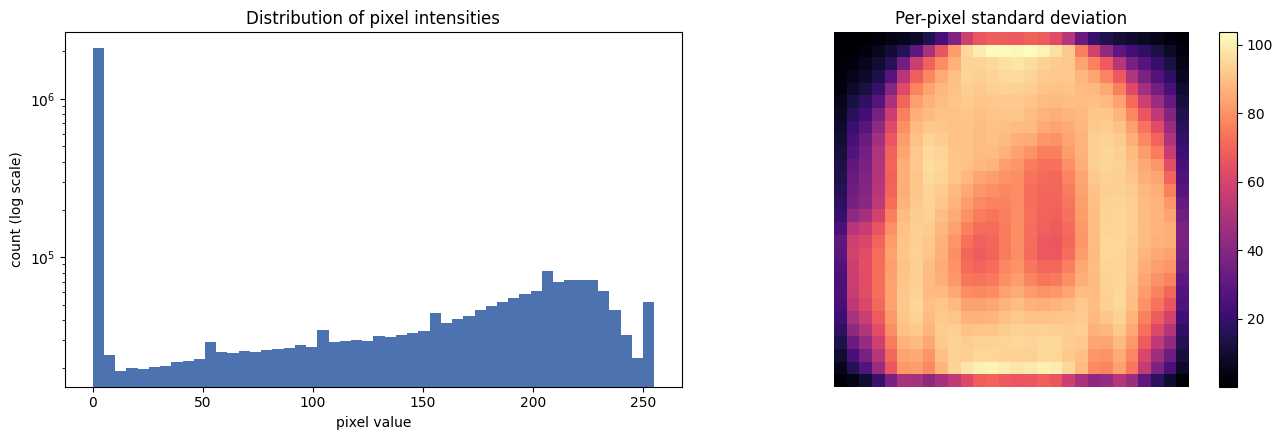

Per-pixel standard deviation -- min: 0.09255 | median: 81.3087 | max: 103.6537
Pixels with a standard deviation below 0.01 (of 255): 11 out of 784


In [17]:
f, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribution of pixel intensities (subsampled for speed)
ax[0].hist(X_train_raw[:5000].ravel(), bins=50, color='#4C72B0')
ax[0].set_yscale('log')
ax[0].set_title('Distribution of pixel intensities')
ax[0].set_xlabel('pixel value')
ax[0].set_ylabel('count (log scale)')

# Per-pixel standard deviation, shown back in 28x28 image space
pixel_std = X_train_raw.reshape(len(X_train_raw), -1).std(axis=0)
im = ax[1].imshow(pixel_std.reshape(28, 28), cmap='magma')
ax[1].set_title('Per-pixel standard deviation')
ax[1].axis('off')
f.colorbar(im, ax=ax[1], fraction=0.046)

plt.tight_layout()
plt.show()

print("Per-pixel standard deviation -- min: %.5f | median: %.4f | max: %.4f"
      % (pixel_std.min(), np.median(pixel_std), pixel_std.max()))
print("Pixels with a standard deviation below 0.01 (of 255):", int((pixel_std < 0.01 * 255).sum()), "out of 784")

Two things to take away:

1. The intensity histogram is dominated by a huge spike at 0 (the background) with a long tail spread over the rest of the range -- note the logarithmic y-axis, without it the tail would be invisible.
2. The variance map shows a bright blob in the middle and a dark frame around the edges. The informative pixels are in the centre; the border pixels barely change at all.

This is the reason we will **not** use `sklearn`'s `StandardScaler` here, even though it was the natural choice for tabular data. `StandardScaler` standardizes every feature *independently*, dividing each pixel by its own standard deviation. In this dataset no pixel is perfectly constant, so nothing would crash -- but the quietest border pixel has a standard deviation of only 0.00036 (on a 0-1 scale), so scaling it to unit variance would multiply it, and whatever sensor noise it contains, by about **2755**. Around a dozen pixels have a standard deviation below 0.01. We would be handing the network a set of features whose loudest signal is pure noise.

There is a second, more conceptual reason: per-pixel scaling destroys the *relative* intensities that make an image an image. Two pixels of equal brightness in the original would end up with different values purely because of where they sit in the frame. For images the standard practice is to rescale every pixel by the **same** two numbers, and that is what we do next.

### 2 - Data Preprocessing

Thanks to the EDA, we know what we are dealing with. Now it is time to prepare the data. There are three things to do:

1. **Flatten** each 28x28 image into a 784-dimensional vector. An MLP has no notion of a 2D grid -- it just sees a list of numbers. (This is a genuine limitation: we are throwing away the spatial structure of the image, and it is exactly what convolutional networks are invented to fix. You will meet them in a later assignment.)
2. **Scale** the pixel values from `[0, 255]` to `[0, 1]` by dividing by 255. Neural networks train much better on small, centred inputs.
3. **Normalize** using a single global mean and standard deviation computed over the training set, rather than per-pixel statistics. This avoids the noise-amplification problem we just found, preserves the relative brightness structure of each image, and is exactly what `torchvision.transforms.Normalize` does for this dataset.

As always, the statistics are computed on the **training set only** and then applied unchanged to the test set. Computing them over the whole dataset would leak information about the test set into our preprocessing.

In [18]:
# 1. Flatten: (n, 28, 28) -> (n, 784), and 2. scale to [0, 1]
train_x = X_train_raw.reshape(len(X_train_raw), -1).astype(np.float32) / 255.0
test_x  = X_test_raw.reshape(len(X_test_raw), -1).astype(np.float32) / 255.0

# 3. Normalize with statistics from the TRAINING set only
pixel_mean = train_x.mean()
pixel_std  = train_x.std()
print("Training set pixel mean: %.4f | std: %.4f" % (pixel_mean, pixel_std))

train_x_scaled = (train_x - pixel_mean) / pixel_std
test_x_scaled  = (test_x  - pixel_mean) / pixel_std

train_y = y_train_raw
test_y  = y_test_raw

print("\nAfter scaling -- train mean: %.4f, train std: %.4f" % (train_x_scaled.mean(), train_x_scaled.std()))
print("             -- test  mean: %.4f, test  std: %.4f  (not exactly 0/1, and that is correct:"
      % (test_x_scaled.mean(), test_x_scaled.std()))
print("                the test set is normalized with the TRAINING statistics, not its own)")

Training set pixel mean: 0.2860 | std: 0.3530

After scaling -- train mean: 0.0000, train std: 1.0000
             -- test  mean: 0.0023, test  std: 0.9984  (not exactly 0/1, and that is correct:
                the test set is normalized with the TRAINING statistics, not its own)


One last step for Problem 2. Our NumPy network outputs a $(10, m)$ matrix of probabilities, so the labels have to be in the same format: **one-hot encoded**. The integer label `5` ("Sandal") becomes a vector of ten numbers that is 1 in position 5 and 0 everywhere else.

We also transpose the data into the `(features, samples)` orientation that the functions of Problem 1 expect.

**Note.** In Problem 3 you will see that PyTorch does *not* want one-hot labels: `nn.CrossEntropyLoss` takes the integer class index directly and one-hot encodes internally. This one-hot step is a requirement of our hand-written NumPy implementation, not of the task itself.

In [19]:
def one_hot(labels, n_classes=10):
    """Turn an array of integer labels into a one-hot matrix of shape (n_classes, n_samples)."""
    return np.eye(n_classes, dtype=np.float32)[labels].T


# Transpose to (features, samples) -- the orientation used throughout Problem 1
train_x_np = train_x_scaled.T          # (784, 60000)
test_x_np  = test_x_scaled.T           # (784, 10000)

train_y_np = one_hot(train_y)          # (10, 60000)
test_y_np  = one_hot(test_y)           # (10, 10000)

print("Shape of the training set   :", train_x_np.shape)
print("Shape of the training labels:", train_y_np.shape)
print("Shape of the testing set    :", test_x_np.shape)
print("Shape of the testing labels :", test_y_np.shape)

print("\nExample -- label %d (%s) becomes the one-hot column:" % (train_y[0], class_names[train_y[0]]))
print(train_y_np[:, 0].astype(int))

Shape of the training set   : (784, 60000)
Shape of the training labels: (10, 60000)
Shape of the testing set    : (784, 10000)
Shape of the testing labels : (10, 10000)

Example -- label 9 (Ankle boot) becomes the one-hot column:
[0 0 0 0 0 0 0 0 0 1]


#### Question 4 &mdash; whose statistics?

We computed `pixel_mean` and `pixel_std` on the **training set only**, then used those same two numbers to normalize the test set. Notice what that means: the normalized test set does *not* have mean 0 and std 1.

1. Why not just normalize the test set with its own statistics, so it comes out properly centred?
2. At deployment, a single new image arrives from a user. What would "use its own statistics" even mean?

<details>
<summary><i>Think it through, then click here.</i></summary>

**1.** Because that would be **data leakage**. The test set is a stand-in for data you have never seen; the moment your preprocessing consults it, you have used it, and your test score stops being an honest estimate of real-world performance. The rule generalizes far beyond normalization: *any* quantity fitted from data -- scaler statistics, PCA components, vocabulary, imputation values, feature selection -- must be fitted on train and merely *applied* to test.

**2.** This is the question that makes it click. Normalizing one image by its own mean and standard deviation is a *different transformation* for every image, so an identical garment photographed twice would be fed to the network as two different inputs. The model was trained to expect one specific, fixed transformation. Preprocessing must be a frozen function that ships with the model -- which is exactly why those two numbers are computed once, on the training set, and then never touched again.

The residual mismatch you see printed above is not a bug. It is the honest, small difference between the training distribution and the test distribution, and hiding it would be the error.

</details>

### 3 - Train your model

Once the data is ready, let's train our model! In general, you will follow the Deep Learning methodology to build a model:

    1. Initialize parameters / Define hyperparameters

    2. Loop for num_iterations:
        a. Forward propagation
        b. Compute cost function
        c. Backward propagation
        d. Update parameters (using parameters, and grads from backprop)

    3. Use trained parameters to predict labels

Implement our generic $L$-layer neural network using the helper functions we have implemented previously!

In [20]:
def L_layer_model(X, Y, layers_dims, learning_rate, num_iterations, print_cost=None):
    """
    Implements a L-layer neural network.

    Arguments:
    X -- data, numpy array of shape (n_features, number of examples)
    Y -- true "label" matrix, one-hot encoded, of shape (n_classes, number of examples)
    layers_dims -- list containing the input size and each layer size, of length (number of layers + 1).
    learning_rate -- learning rate of the gradient descent update rule
    num_iterations -- number of iterations of the optimization loop
    print_cost -- if set to N, it prints the cost every N steps

    Returns:
    parameters -- parameters learnt by the model. They can then be used to predict.
    """

    np.random.seed(1)
    costs = []                         # keep track of cost

    # Parameters initialization.
    parameters = initialize_parameters(layers_dims)

    # Loop (gradient descent)
    for i in range(0, num_iterations):

        # Forward propagation
        y_pred, caches = L_model_forward(X, parameters)

        # Compute cost
        cost = compute_cost(y_pred, Y)

        # Backward propagation
        grads = L_model_backward(y_pred, Y, caches)

        # Update parameters
        parameters = update_parameters(parameters, grads, learning_rate)

        # Print the cost every X iterations
        if print_cost and i % print_cost == 0:
            accuracy = np.mean(np.argmax(y_pred, axis=0) == np.argmax(Y, axis=0))
            print("Cost after iteration %i: %f  (train accuracy: %.4f)" % (i, cost, accuracy))
            costs.append(cost)

    # plot the cost
    plt.figure(figsize=(4,3))
    plt.plot(np.squeeze(costs))
    plt.ylabel('cost')
    plt.xlabel('iterations (per %s)' % print_cost)
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()

    return parameters

Now you design the network. Two of the numbers are not up to you -- the data and the task fix them -- and the rest are.

A word on the learning rate before you start. It is the single hyperparameter most likely to make your training look "broken", and its two failure modes look completely different: too **low** and the cost drifts down insultingly slowly; too **high** and it lurches around or shoots up to `nan`. You want the largest value that still decreases smoothly. You will not find it by reasoning about it -- try a few and look at the curve.

Budget your patience: 200 iterations takes around a minute and a half, and that is for a *tiny* network by modern standards. It should give you a feel for why nobody trains models in pure NumPy.

**Note.** The data has already been transposed to `(n_features, n_samples)` in the preprocessing step above, which is the orientation the forward function expects.

Cost after iteration 0: 2.420823  (train accuracy: 0.1164)
Cost after iteration 20: 0.753853  (train accuracy: 0.7479)
Cost after iteration 40: 0.646329  (train accuracy: 0.7580)
Cost after iteration 60: 0.584792  (train accuracy: 0.7835)
Cost after iteration 80: 0.544015  (train accuracy: 0.8050)
Cost after iteration 100: 0.544087  (train accuracy: 0.8017)
Cost after iteration 120: 0.475844  (train accuracy: 0.8278)
Cost after iteration 140: 0.474296  (train accuracy: 0.8267)
Cost after iteration 160: 0.454166  (train accuracy: 0.8333)
Cost after iteration 180: 0.437825  (train accuracy: 0.8428)


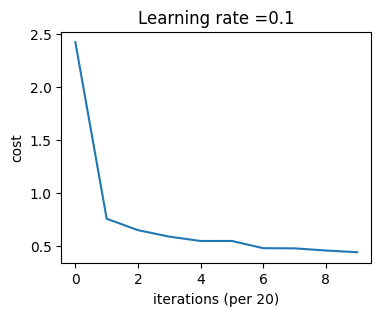

In [21]:
np.random.seed(1)

# ---------------------------------------------------------------- YOUR DECISION -----
# Define the architecture, as a list: [input, hidden_1, ..., hidden_n, output]
#
#   - The FIRST number is forced on you by the data. What is it, and why?
#   - The LAST number is forced on you by the task. What is it, and why?
#   - Everything in between is genuinely your choice: how many hidden layers,
#     and how wide should each one be?
#
# Do not look up a "correct" answer -- pick something, run it, and look at the cost curve.
# Then change it and run it again. That loop is the entire exercise.
layers_dims = [784, 128, 64, 10]

# Now the optimization. Try 0.01, then 0.1, then 1.0, and watch what the cost curve does.
learning_rate  = 0.1
num_iterations = 200
# ------------------------------------------------------------------------------------

# Train model
parameters = L_layer_model(train_x_np,
                           train_y_np,
                           layers_dims,
                           num_iterations = num_iterations,
                           learning_rate = learning_rate,
                           print_cost = 20)

Let's see how this hand-written model does on the test set. To predict, we simply run the forward pass and take the class with the highest probability (`argmax` over the class axis).

In [22]:
def predict_numpy(X, parameters):
    """Run the forward pass and return the predicted class index for every sample."""
    y_pred, _ = L_model_forward(X, parameters)
    return np.argmax(y_pred, axis=0)

train_pred = predict_numpy(train_x_np, parameters)
test_pred  = predict_numpy(test_x_np,  parameters)

print("Train accuracy: %.4f" % np.mean(train_pred == train_y))
print("Test accuracy : %.4f" % np.mean(test_pred  == test_y))

Train accuracy: 0.8377
Test accuracy : 0.8273


Results are not that impressive and a bit slow. We are skipping some important considerations during the optimization process, but we will see in the next problem how easy it is to deal with them when implementing a NN model using Deep Learning frameworks. The main goal here was to understand the maths, statistics, and operations behind Deep Learning that are crucial during the decision-making stage of data preprocessing, building the model architecture, and configuring the training/testing.

The key limitation is that we performed **full-batch** gradient descent: 200 iterations means the parameters were updated only 200 times, each time using all 60,000 images to compute a single step. In Problem 3 we will see what happens when we take many more, noisier steps instead.

## Problem 3. PyTorch Implementation

Time to create our classifier in PyTorch! We will design a very simple MLP classifier consisting of 3 hidden layers. Take into consideration that the design of a classifier needs time and a proper practice would be to either test the configurations or simply select an existing architecture such as ResNet or EfficientNet.

Where a framework like Keras hides everything behind `.compile()` and `.fit()`, PyTorch splits the job into a handful of explicit objects that you will meet one by one in this problem:

| Object | Role |
| --- | --- |
| `nn.Sequential` / `nn.Module` | the model and its layers |
| `TensorDataset` + `DataLoader` | how the data is batched and shuffled |
| `nn.CrossEntropyLoss` | the loss (cost) function |
| `torch.optim.SGD` | the optimizer, i.e. the parameter update rule |
| the training loop | written by you -- it glues the four objects above together |

In [23]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility: this seeds the RNG used to initialize the weights and to shuffle the batches
torch.manual_seed(0)

# PyTorch is explicit about *where* tensors live. Tensors and model must be on the same device.
# On a CPU-only session this resolves to "cpu"; turning the GPU accelerator on is enough for it
# to become "cuda", and the rest of the code below does not change at all.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Using device:", device)

PyTorch version: 2.10.0+cu128
Using device: cuda


### 1 - Model Architecture and Training

We will design the same classifier as before with ReLU as activation function. Remember to indicate the right input dimension in the first layer. What about the last layer? How many classes are we predicting? What activation function should we choose considering that we are aiming for a classification problem?

**Note:** In PyTorch there are two ways of defining a model: `nn.Sequential`, where layers are stacked sequentially, and subclassing `nn.Module` (writing your own `__init__` and `forward`), a more verbose but far more flexible way to create models. We will use the `nn.Sequential` approach for simplicity.

**Note on the output layer.** In Problem 1 the last layer applied a softmax and the cost function received probabilities. In PyTorch the idiomatic choice is the opposite: the model returns the 10 raw scores of the last linear layer (the **logits**), and the softmax is folded into the loss by using `nn.CrossEntropyLoss`. Mathematically it is exactly the same categorical cross-entropy cost you implemented in Problem 1, but computing both in a single operation is numerically stable -- it applies the same log-sum-exp trick you saw in our `softmax()` helper, and it never materializes the probabilities at all. Remember the consequence: **the model no longer outputs probabilities**, so you must apply `torch.softmax()` yourself if you ever need them. For simply picking the predicted class you do not, because `argmax` over the logits gives the same answer as `argmax` over the probabilities.

**Note on the labels.** `nn.CrossEntropyLoss` expects the targets as **integer class indices** of shape `(N,)` and dtype `int64` -- *not* one-hot encoded, and not float. It does the one-hot step internally. This is a very common source of confusion when moving from a hand-written implementation to PyTorch.

**Note on initialization.** `nn.Linear` initializes its weights with Kaiming-uniform by default. To keep the very same LeCun initialization we used in `initialize_parameters()` in Problem 1 (weights `~ N(0, 1/fan_in)`, biases at zero) we apply it explicitly with `model.apply()`, which walks over every submodule of the network.

In [24]:
def lecun_normal_init(module):
    """
    LeCun Normal initialization: W ~ N(0, 1/fan_in), b = 0.

    This is the same rule used in `initialize_parameters()` in Problem 1
    (`np.random.randn(...) / np.sqrt(layer_dims[l-1])`).

    `nn.Module.apply()` calls this function on every submodule of the model,
    so we only act on the `nn.Linear` ones.
    """
    if isinstance(module, nn.Linear):
        fan_in = module.in_features
        nn.init.normal_(module.weight, mean=0.0, std=1.0 / np.sqrt(fan_in))
        nn.init.zeros_(module.bias)


def mlp_model():

    torch.manual_seed(0)  # same starting point every time we rebuild the model

    # ------------------------------------------------------------ YOUR DECISION -----
    # Rebuild the SAME architecture you chose in Problem 2, using PyTorch layers.
    #
    #   nn.Linear(in_features, out_features)  is one (W, b) pair -- one entry of your
    #                                         layers_dims list turning into the next
    #   nn.ReLU()                             is an activation, and it is a LAYER here
    #
    # Two things to get right, and both are easy to get wrong:
    #   - the widths have to chain: each Linear takes in what the previous one put out
    #   - do NOT put an activation after the last Linear. Re-read the note above if
    #     you are not sure why.
    mlp = nn.Sequential(
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )
    # --------------------------------------------------------------------------------

    mlp.apply(lecun_normal_init)
    mlp = mlp.to(device)

    # PyTorch has no `.summary()`: printing the module shows the layer stack
    print(mlp)
    n_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
    print("\nTrainable parameters:", n_params)

    return mlp

Once we have defined our model, we will proceed to train it! In PyTorch we need three ingredients:

1. A **loss function** (which one is the most suitable for this task?). Since our model returns logits over 10 classes, we use `nn.CrossEntropyLoss`, the categorical cross-entropy with the softmax built in.
2. An **optimizer**. There are several options available (feel free to explore them: https://pytorch.org/docs/stable/optim.html) but for now, we'll make use of Stochastic Gradient Descent (SGD) with a fixed learning rate of 0.1. Note that in PyTorch the optimizer must be told *which* tensors it is allowed to update, hence the `mlp.parameters()` argument.
3. A **`DataLoader`**, which wraps the dataset and takes care of batching it (and optionally reshuffling it every epoch).

And then, instead of `.compile()` and `.fit()`, **we write the training loop ourselves**. Every iteration repeats exactly the same steps you implemented by hand in Problem 1:

```python
optimizer.zero_grad()                # 1. clear the gradients of the previous iteration
logits = model(x_batch)              # 2. forward propagation
loss = criterion(logits, y_batch)    # 3. compute the cost
loss.backward()                      # 4. backward propagation (autograd does it for you)
optimizer.step()                     # 5. update the parameters
```

Compare this with `L_layer_model()` in Problem 2: it is the very same loop, except that `loss.backward()` replaces your `L_model_backward()` and `optimizer.step()` replaces your `update_parameters()`.

The only genuinely new step is `optimizer.zero_grad()`. PyTorch **accumulates** gradients into the `.grad` attribute of each parameter instead of overwriting them, so forgetting this line would sum up the gradients of every previous iteration and the training would silently diverge.

**Note**: In this case, we've used accuracy as a metric to evaluate our ML algorithm. Fashion-MNIST is perfectly balanced, which makes accuracy a fair summary here. On an imbalanced dataset it can mislead you badly, and metrics such as the F-score or MCC, or a per-class breakdown, become far more informative.

In [25]:
# PyTorch works with tensors, so we convert our NumPy data first.
# Note the orientation: PyTorch uses (samples, features), the transpose of what Problem 1 used.
# And note the label dtype: int64 class indices, NOT one-hot -- CrossEntropyLoss requires this.
X_train_t = torch.tensor(train_x_scaled, dtype=torch.float32)   # (60000, 784)
y_train_t = torch.tensor(train_y, dtype=torch.int64)            # (60000,)
X_test_t  = torch.tensor(test_x_scaled, dtype=torch.float32)    # (10000, 784)
y_test_t  = torch.tensor(test_y, dtype=torch.int64)             # (10000,)

train_tensor_dataset = TensorDataset(X_train_t, y_train_t)

print("X_train_t:", tuple(X_train_t.shape), X_train_t.dtype)
print("y_train_t:", tuple(y_train_t.shape), y_train_t.dtype, "-> values are class indices:", y_train_t[:8].tolist())

X_train_t: (60000, 784) torch.float32
y_train_t: (60000,) torch.int64 -> values are class indices: [9, 0, 0, 3, 0, 2, 7, 2]


#### Question 5 &mdash; two ways to say "Sandal"

In Problem 2 you one-hot encoded the labels into a `(10, m)` matrix. Here you pass `y_train_t`, a flat vector of `int64` class indices, and `nn.CrossEntropyLoss` refuses one-hot targets in this form.

1. Both encodings express the same information. Why does PyTorch prefer the integer one?
2. The tensors are also transposed relative to Problem 1: `(samples, features)` here, `(features, samples)` there. Does either orientation make the mathematics different?

<details>
<summary><i>Think it through, then click here.</i></summary>

**1.** Efficiency, and the softmax shortcut. Remember what the cost actually reduces to: because the one-hot vector is zero everywhere except the true class, the whole sum collapses to `-log(probability of the correct class)`. To evaluate that, you do not need a 10-element vector of mostly zeros -- you need *one index* telling you which entry to look up. `CrossEntropyLoss` goes straight to that entry. With 10 classes the saving is trivial; with a 50,000-word vocabulary in a language model, materializing one-hot vectors would be absurd.

**2.** No. It is pure convention, and it is a genuine annoyance when moving between codebases. Our NumPy code computes `Z = W A + b` with data in columns; PyTorch's `nn.Linear` computes `Z = X Wᵀ + b` with data in rows. Identical arithmetic, transposed bookkeeping. The reason PyTorch puts samples first is that the batch dimension comes first everywhere else in the ecosystem too -- images are `(batch, channels, height, width)`.

Getting this wrong is one of the most common early bugs, and it usually surfaces as a shape error rather than a wrong answer, which is a mercy.

</details>

**A note on `TensorDataset` vs the `torchvision` dataset.** We could have passed a `transform` to `datasets.FashionMNIST` and wrapped it directly in a `DataLoader` -- that is the idiomatic pattern, and the right one when your data is too large to fit in memory or when you want random augmentation on every epoch. Here the whole dataset is only ~180 MB as float32 and needs no augmentation, so we convert it once into tensors and use a `TensorDataset`. That avoids re-running the Python-level transform on 60,000 images at every single epoch, which would dominate the runtime.

In [26]:
def train_model(model, loader, criterion, optimizer, epochs, print_every=None):
    """
    The PyTorch equivalent of Keras' `model.fit()` -- we simply write it ourselves.

    Arguments:
    model        -- the nn.Module to train
    loader       -- a DataLoader yielding (x_batch, y_batch) pairs
    criterion    -- the loss function, e.g. nn.CrossEntropyLoss()
    optimizer    -- the optimizer, e.g. torch.optim.SGD(model.parameters(), lr=0.1)
    epochs       -- number of passes over the whole dataset
    print_every  -- if set to N, print loss and accuracy every N epochs

    Returns:
    history -- dict with the per-epoch "loss" and "accuracy" lists
    """

    history = {"loss": [], "accuracy": []}

    for epoch in range(epochs):

        model.train()  # training mode (only matters once we add dropout / batch norm)
        running_loss, running_correct, n_seen = 0.0, 0, 0

        for x_batch, y_batch in loader:

            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()               # 1. reset the gradients
            logits = model(x_batch)             # 2. forward propagation
            loss = criterion(logits, y_batch)   # 3. compute the cost
            loss.backward()                     # 4. backward propagation
            optimizer.step()                    # 5. update the parameters

            # Accumulate the metrics, weighting each batch by its size so that a last
            # (smaller) batch does not count as much as a full one
            batch_size = x_batch.size(0)
            running_loss += loss.item() * batch_size
            with torch.no_grad():  # metrics are not part of the computational graph
                predicted = logits.argmax(dim=1)   # most likely class for each image
                running_correct += (predicted == y_batch).sum().item()
            n_seen += batch_size

        history["loss"].append(running_loss / n_seen)
        history["accuracy"].append(running_correct / n_seen)

        if print_every and ((epoch + 1) % print_every == 0 or epoch == 0):
            print(f"Epoch {epoch + 1} - loss: {history['loss'][-1]:.4f}"
                  f" - accuracy: {history['accuracy'][-1]:.4f}")

    return history

Let's start by reproducing exactly what we did in Problem 2: **full-batch** gradient descent for 200 epochs. One batch containing all 60,000 images means one parameter update per epoch, so 200 updates in total -- the same budget the NumPy model had.

In [27]:
# One single batch containing the whole dataset (full-batch gradient descent),
# the same optimization setting we used in Problem 2
loader = DataLoader(train_tensor_dataset, batch_size=len(train_tensor_dataset), shuffle=False)

mlp = mlp_model()

# ---------------------------------------------------------------- YOUR DECISION -----
# Which loss fits a 10-class problem whose model outputs raw logits? Your options:
#
#     nn.MSELoss()             nn.BCELoss()
#     nn.BCEWithLogitsLoss()   nn.CrossEntropyLoss()
#
# Two of these are for binary problems and one is for regression. If you are not sure,
# guess, run it, and read the error -- PyTorch's complaint is itself informative.
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(mlp.parameters(), lr=0.1)
# ------------------------------------------------------------------------------------

history = train_model(mlp, loader, criterion, optimizer,
                      epochs=200,
                      print_every=20)

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)

Trainable parameters: 109386
Epoch 1 - loss: 2.3213 - accuracy: 0.1018
Epoch 20 - loss: 0.7775 - accuracy: 0.7215
Epoch 40 - loss: 0.6616 - accuracy: 0.7519
Epoch 60 - loss: 0.6003 - accuracy: 0.7802
Epoch 80 - loss: 0.5360 - accuracy: 0.8064
Epoch 100 - loss: 0.4988 - accuracy: 0.8177
Epoch 120 - loss: 0.4864 - accuracy: 0.8266
Epoch 140 - loss: 0.4697 - accuracy: 0.8280
Epoch 160 - loss: 0.4543 - accuracy: 0.8327
Epoch 180 - loss: 0.4439 - accuracy: 0.8409
Epoch 200 - loss: 0.4215 - accuracy: 0.8494


Plot accuracy and loss curves. It is quite usual to see the plot of the loss curves showing overfitting. This is a common problem in machine learning where a model learns not only the underlying patterns in the training data but also the noise and outliers. This means that the model can not generalize anymore with the training data and starts to "memorize" the samples it is training with. There exist several techniques to address this problem, but we will learn more about them in following assignments.

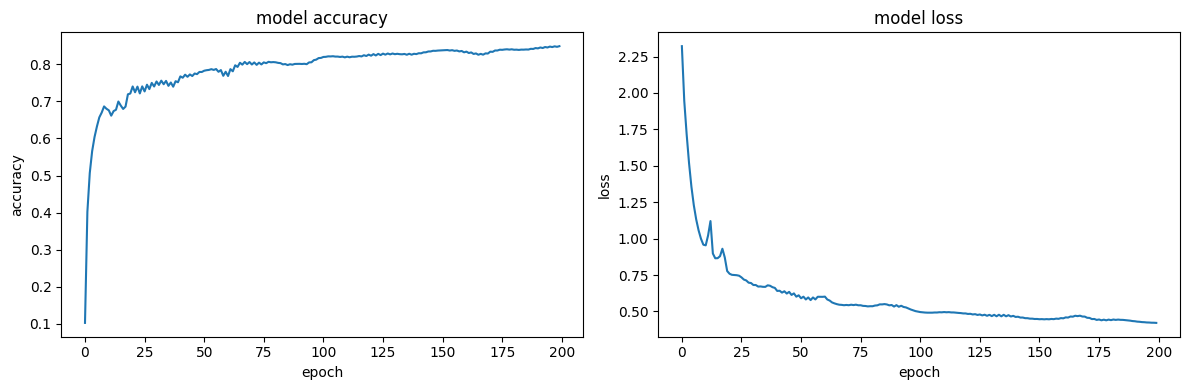

In [28]:
f,ax=plt.subplots(1,2,figsize=(12,4))

ax[0].plot(history['accuracy'])
ax[0].set_title('model accuracy')
ax[0].set_ylabel('accuracy')
ax[0].set_xlabel('epoch')

ax[1].plot(history['loss'])
ax[1].set_title('model loss')
ax[1].set_ylabel('loss')
ax[1].set_xlabel('epoch')

plt.tight_layout()
plt.show()

One way to improve the results is to use a batch size instead of the whole dataset. This technique provides a balance between memory usage, computational efficiency, and model performance. Using smaller batches introduces some randomness (stochasticity) in the updates, which can help the model escape local minima and potentially reach a better solution. In general, it allows for faster training and better generalization, especially when dealing with large datasets. Run the same experiment but using a batch size of 128.

In PyTorch this is just an argument of the `DataLoader`: `batch_size=128`. We also set `shuffle=True`, so the images are reshuffled into different batches at every epoch -- that reshuffling is where the *stochastic* in Stochastic Gradient Descent actually comes from, and without it the model would see the exact same sequence of batches over and over again.

Watch what happens to the number of **parameter updates**. With the full batch we performed 200 updates in total, one per epoch. With a batch size of 128 over 60,000 images we get 469 updates *per epoch* -- so even training for just **30 epochs** gives us 14,070 updates, about 70 times more than the full-batch run made in 200. That is why we cut the number of epochs here: we no longer need 200 of them. The wall-clock time per epoch goes up, but the model learns vastly more per epoch, and this single change is worth more than everything else in this notebook.

#### Question 6 &mdash; predict before you run

You are about to train with mini-batches. Before you execute the cell, commit to answers:

1. The full-batch run made **200** parameter updates in 200 epochs. With `batch_size=128` over 60,000 images, how many updates happen in a *single* epoch?:
    - [60000/128] = 469
2. So: would you rather have 200 epochs of full-batch, or 30 epochs of batch-128?:
    - 30 epochs of batch-128 since, across 30 epochs, the model receives 30 * 469 = 14070 parameter updates compared to just 200.
3. Each mini-batch gradient is computed from 128 images instead of 60,000, so it is a much **noisier** estimate of the true gradient. Why doesn't that wreck the training?:
    - Because taking hundreds of frequent, imperfect step moves the model forward much faster than making a sinlge precise step because the progress adds up while the errors cancel out.

<details>
<summary><i>Answer all three first, then run the cell and check.</i></summary>

**1.** `ceil(60000 / 128) = 469` updates per epoch.

**2.** 30 epochs of batch-128 gives `469 x 30 = 14,070` updates -- about 70 times more than the full-batch run managed in 200 epochs, at a fraction of the wall-clock cost. It is not close.

**3.** Two reasons. First, a noisy step in roughly the right direction, taken 469 times, beats a perfect step taken once -- the errors average out over many updates while the progress accumulates. Second, the noise is actively *useful*: it can knock the model out of sharp local minima and saddle points that full-batch descent would settle into, and it acts as a mild regularizer. This is why nobody uses true full-batch gradient descent in practice, and why the "stochastic" in SGD is a feature rather than a compromise.

The honest caveat: noise is only useful up to a point. Batch size 1 is usually too noisy to converge well, and very large batches lose the benefit. 32-256 is the conventional sweet spot.

</details>

In [29]:
# ---------------------------------------------------------------- YOUR DECISION -----
# Split the data into mini-batches instead of one giant batch.
#   batch_size -- how many images contribute to a single parameter update?
#   shuffle    -- should the batches be reshuffled every epoch? (re-read the text above)
#   epochs     -- you now get many updates per epoch, so you need far FEWER epochs
#                 than the 200 above. Start low. You can always run the cell again.
batch_size = 128
shuffle    = True
n_epochs   = 30
# ------------------------------------------------------------------------------------

loader = DataLoader(train_tensor_dataset, batch_size=batch_size, shuffle=shuffle)

print("Batches per epoch:", len(loader))
print("Total parameter updates:", len(loader) * n_epochs, "  (the full-batch run made 200)")

mlp = mlp_model()

# reuse the loss you chose above; the optimizer must be rebuilt for the new model.
# The learning rate stays at 0.1 on purpose -- change one thing at a time.
optimizer = torch.optim.SGD(mlp.parameters(), lr=0.1)

history = train_model(mlp, loader, criterion, optimizer,
                      epochs=n_epochs,
                      print_every=5)

Batches per epoch: 469
Total parameter updates: 14070   (the full-batch run made 200)
Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)

Trainable parameters: 109386
Epoch 1 - loss: 0.5338 - accuracy: 0.8056
Epoch 5 - loss: 0.2993 - accuracy: 0.8900
Epoch 10 - loss: 0.2382 - accuracy: 0.9116
Epoch 15 - loss: 0.1971 - accuracy: 0.9272
Epoch 20 - loss: 0.1683 - accuracy: 0.9372
Epoch 25 - loss: 0.1436 - accuracy: 0.9479
Epoch 30 - loss: 0.1241 - accuracy: 0.9546


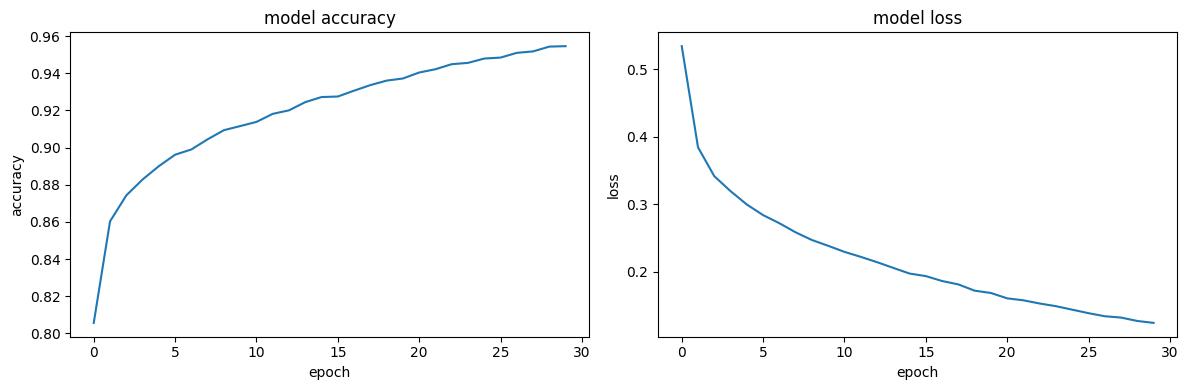

In [30]:
f,ax=plt.subplots(1,2,figsize=(12,4))

ax[0].plot(history['accuracy'])
ax[0].set_title('model accuracy')
ax[0].set_ylabel('accuracy')
ax[0].set_xlabel('epoch')

ax[1].plot(history['loss'])
ax[1].set_title('model loss')
ax[1].set_ylabel('loss')
ax[1].set_xlabel('epoch')

plt.tight_layout()
plt.show()

Note that we only trained for **30 epochs** here instead of 200, and still ended up far ahead of both the full-batch PyTorch run and the NumPy model of Problem 2. That is the point: what matters is not how many times you sweep over the data, but how many useful parameter updates you make.

### 2 - Predictions on test set

Once the model has been trained, we can make predictions on our test set. Predict the class scores for the test set data, convert them into a class prediction by taking the `argmax` over the 10 classes, compute the accuracy and plot a confusion matrix.

There is no `.predict()` in PyTorch, but inference is only a few lines. Two of them are important habits:

* `model.eval()` switches the model to evaluation mode. It changes nothing in this particular MLP, but as soon as the network contains dropout or batch normalization, forgetting it silently corrupts your predictions.
* `with torch.no_grad():` tells autograd not to build the computational graph. We are not going to backpropagate here, so this saves both memory and time.

Remember that our model returns **logits**, not probabilities. For picking the predicted class that makes no difference -- softmax is monotonic, so `argmax(logits) == argmax(softmax(logits))` -- which is why we can take the `argmax` directly. We compute the probabilities separately only because they are useful to look at.

The confusion matrix is a layout that allows visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class. The main diagonal represents the matches between the true and the predicted labels. With 10 classes it becomes far more informative than in a binary problem: it tells us not just *how often* the model is wrong, but *which garments it mixes up*.

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix


def plot_confusion_matrix(cm: np.array,
                          classes: list,
                          title: str = 'Confusion matrix',
                          cmap: object = plt.cm.YlGn):
    """
    This function prints and plots the confusion matrix (cm), normalized by row.

    Parameters:
    ----------
    cm : np.array
        Confusion matrix.
    classes : list
        Data labels.
    title : str, optional
        Title of the image. The default is 'Confusion matrix'.
    cmap : object, optional
        Color map. The default is 'plt.cm.YlGn'.

    Returns
    -------
    None

    """

    plt.figure(figsize=(9, 9), dpi=110, facecolor='w', edgecolor='k')

    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm_norm.max() / 2.

    plt.imshow(cm_norm, interpolation='nearest', cmap=cmap, vmin=0, vmax=1)
    plt.title(title, fontsize=11)
    plt.colorbar(fraction=0.046)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=8, rotation=45, ha='right')
    plt.yticks(tick_marks, classes, fontsize=8)

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        cm = cm.astype('int')
        plt.text(j, i, (("%.2f\n(%d)" % (cm_norm[i, j], cm[i, j]))),
                     horizontalalignment="center", verticalalignment="center", fontsize=6,
                     color="white" if cm_norm[i, j] > thresh else "black")

    plt.ylabel('True Label', fontsize=9)
    plt.xlabel('Predicted Label', fontsize=9)
    plt.tight_layout()

Accuracy test: 0.8844


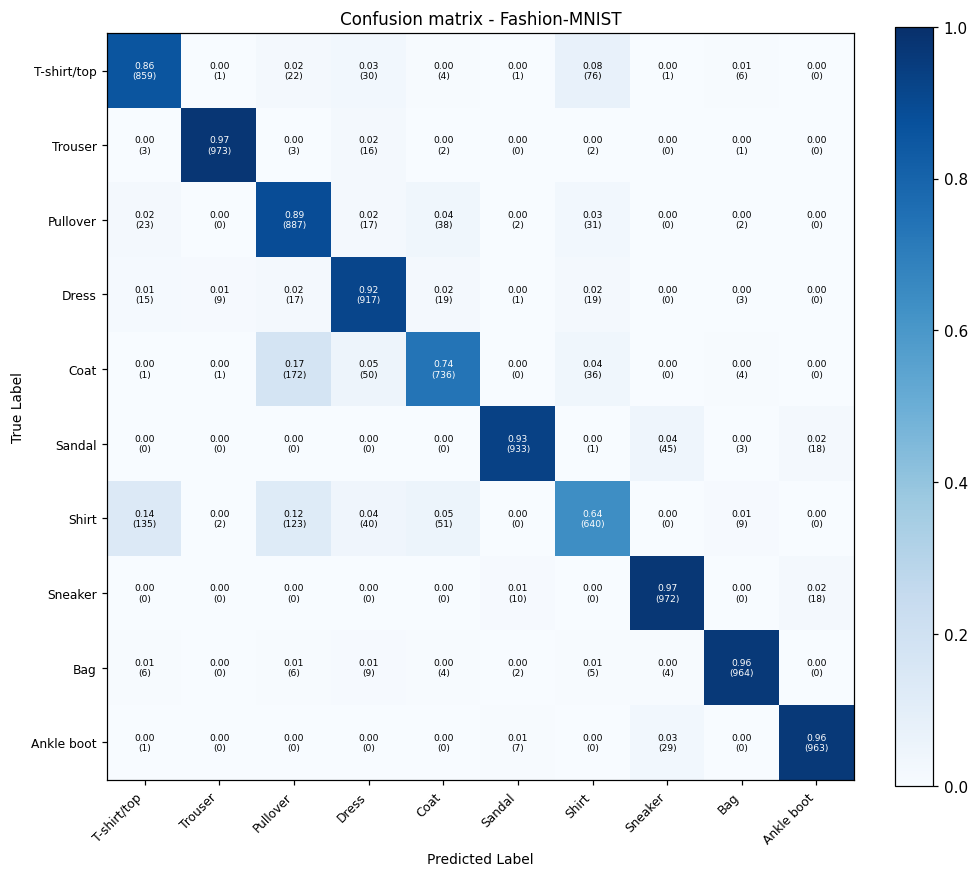

In [32]:
X_test_dev = X_test_t.to(device)

mlp.eval()                                                   # evaluation mode
with torch.no_grad():                                        # no gradients needed for inference
    logits = mlp(X_test_dev)
    probabilities = torch.softmax(logits, dim=1).cpu().numpy()   # logits -> probabilities (for inspection)

# Hint - obtain argmax of the predictions over the class axis
pred_argmax = logits.argmax(dim=1).cpu().numpy()

# Obtain accuracy with argmax
acc_test = accuracy_score(test_y, pred_argmax)
# Obtain confusion matrix with argmax
conf_mat = confusion_matrix(test_y, pred_argmax)

print("Accuracy test:", acc_test)

plot_confusion_matrix(cm=conf_mat, classes=class_names,
                      title='Confusion matrix - Fashion-MNIST', cmap='Blues')

**Now go back to your answer to Question 3.** Look at where the mistakes concentrate. The *Trouser*, *Bag*, *Sandal* and *Ankle boot* rows should be close to perfect, while *Shirt* is almost certainly the worst class by a wide margin -- routinely confused with *T-shirt/top*, *Pullover* and *Coat*. That is exactly what the sample grid and the mean-image plot predicted back in the EDA, and it is a good illustration of why looking at your data first is worth the time.

A per-class breakdown makes the same point in numbers.

#### Question 7 &mdash; the ceiling of this design

Your model plateaus somewhere in the high 80s. Before reaching for a bigger network, notice what you threw away in preprocessing: you **flattened** each 28x28 image into a flat list of 784 numbers.

1. What information does flattening destroy?
2. Here is the test. Take every image in the dataset and shuffle the 784 pixels -- the *same* permutation for every image. How much accuracy would this MLP lose?
3. What kind of layer would fix this, and what does it assume about the data that `nn.Linear` does not?

<details>
<summary><i>Sit with question 2 for a moment before clicking -- it is the interesting one.</i></summary>

**1.** All spatial structure. After flattening, pixel 0 and pixel 1 (side by side in the image) are no more related than pixel 0 and pixel 500. The network has to *learn* adjacency from scratch, from data, for every pair of pixels.

**2.** **None at all.** Not "a little" -- exactly zero. A fixed permutation of the inputs is undone by the same permutation of the first layer's weight columns, so the shuffled problem is precisely as hard for an MLP as the original. This is the sharpest possible statement of the limitation: your model cannot see the image *as an image*. It would classify shredded and reassembled garments just as well, which no human could.

**3.** A **convolutional** layer. It builds in two assumptions an MLP lacks: **locality** (nearby pixels are related, so look at small neighbourhoods) and **translation equivariance** (a sleeve is a sleeve wherever it appears, so reuse the same weights across the whole image). Those two priors are what make the permutation test fail for a CNN -- it would collapse, and that is exactly the point. They also make it far more parameter-efficient: it does not have to spend capacity discovering facts about images that we already know.

That is the subject of the next assignment.

</details>

In [33]:
from sklearn.metrics import classification_report

print(classification_report(test_y, pred_argmax, target_names=class_names, digits=3))

              precision    recall  f1-score   support

 T-shirt/top      0.824     0.859     0.841      1000
     Trouser      0.987     0.973     0.980      1000
    Pullover      0.721     0.887     0.796      1000
       Dress      0.850     0.917     0.882      1000
        Coat      0.862     0.736     0.794      1000
      Sandal      0.976     0.933     0.954      1000
       Shirt      0.790     0.640     0.707      1000
     Sneaker      0.925     0.972     0.948      1000
         Bag      0.972     0.964     0.968      1000
  Ankle boot      0.964     0.963     0.963      1000

    accuracy                          0.884     10000
   macro avg      0.887     0.884     0.883     10000
weighted avg      0.887     0.884     0.883     10000

